In [1]:
import os
import scanpy as sc
import anndata as ad
import numpy as np
from scipy.stats import median_abs_deviation
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import numpy2ri, pandas2ri
from scipy.sparse import csc_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from scipy.sparse import issparse
import rpy2.robjects as ro
import rpy2.robjects.packages as rpackages
from rpy2.robjects import r


In [30]:
sample_list = ["S26_17", "S26_18", "S26_19", "S26_20", "S26_22", "S26_23", "S26_27", "S26_31", "S26_32"]

In [31]:
adata_concat_dict =  {}
for sample in sample_list:
    adata_path = f"/projects/circ_iri/work/sc_analysis/{sample}_preprocessed.h5ad"
    adata = sc.read_h5ad(adata_path)
    adata_concat_dict[sample] = adata


In [32]:
sample_metadata = {
    "S26_17": {"condition":"Sham_LNP_circGFP"},
    "S26_18": {"condition":"Sham_LNP_circGFP"},
    "S26_19": {"condition":"Sham_LNP_circGFP"},
    "S26_20": {"condition":"IRI_LNP_circGFP"},
    "S26_22": {"condition":"IRI_LNP_circGFP"},
    "S26_23": {"condition":"IRI_LNP_circGFP"},
    "S26_27": {"condition":"IRI_LNP_circINSR"},
    "S26_31": {"condition":"IRI_LNP_circINSR"},
    "S26_32": {"condition":"IRI_LNP_circINSR"},
}

In [33]:
for sample, adata in adata_concat_dict.items():
    adata.obs["sample"] = sample
    for key, value in sample_metadata[sample].items():
        adata.obs[key] = value


In [34]:
adata = ad.concat(
    adata_concat_dict,
    label="sample",  # adds column automatically
    join="outer",  # keeps union of genes
    index_unique="-", 
    merge="first"
)

In [35]:
adata.obs

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,...,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,outlier,mt_outlier,soupx_groups,scDblFinder_score,scDblFinder_class,sample,condition
AAACCAAAGCGCCTGA-1-S26_17,1741,7.462789,2887.0,7.968319,15.587115,21.440942,27.779702,37.062695,57.014202,28.0,...,3.0,1.386294,0.103914,False,False,0,0.000078,singlet,S26_17,Sham_LNP_circGFP
AAACCAAAGGCGAGAC-1-S26_17,1458,7.285507,2360.0,7.766840,14.745763,20.932203,28.093220,38.474576,59.406780,32.0,...,1.0,0.693147,0.042373,False,False,0,0.000031,singlet,S26_17,Sham_LNP_circGFP
AAACCAAAGGCTCCGA-1-S26_17,2520,7.832411,5668.0,8.642768,18.719125,25.723359,32.163020,40.508116,56.527876,48.0,...,2.0,1.098612,0.035286,False,False,3,0.022403,singlet,S26_17,Sham_LNP_circGFP
AAACCAAAGGTGCAGA-1-S26_17,886,6.787845,1103.0,7.006695,10.063463,17.225748,26.291931,37.805984,65.004533,16.0,...,0.0,0.000000,0.000000,False,False,4,0.000282,singlet,S26_17,Sham_LNP_circGFP
AAACCAAAGTCGCATA-1-S26_17,1109,7.012115,1730.0,7.456455,14.104046,21.502890,30.635838,42.890173,64.797688,32.0,...,0.0,0.000000,0.000000,False,False,5,0.000566,singlet,S26_17,Sham_LNP_circGFP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTGTACGTTAGCCCA-1-S26_32,755,6.628041,1182.0,7.075809,14.720812,24.619289,35.109983,52.030457,78.426396,7.0,...,1.0,0.693147,0.084602,False,False,0,0.000137,singlet,S26_32,IRI_LNP_circINSR
TGTGTTAGTAGGTCCC-1-S26_32,2209,7.700748,4861.0,8.489205,16.251800,22.197079,29.129809,38.407735,55.996708,38.0,...,7.0,2.079442,0.144003,False,False,11,0.002328,singlet,S26_32,IRI_LNP_circINSR
TGTGTTAGTATGTCCG-1-S26_32,1395,7.241366,2239.0,7.714231,9.870478,16.971862,25.279142,37.114783,60.026798,37.0,...,4.0,1.609438,0.178651,False,False,1,0.006093,singlet,S26_32,IRI_LNP_circINSR
TGTGTTAGTTAACCCG-1-S26_32,721,6.582025,1021.0,6.929517,14.397649,24.191969,34.769833,48.971596,78.354554,21.0,...,5.0,1.791759,0.489716,False,False,3,0.000143,singlet,S26_32,IRI_LNP_circINSR


In [36]:
adata.var

,gene_ids,feature_types,genome,mt,ribo,hb,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells
0610005C13Rik,ENSMUSG00000109644,Gene Expression,GRCm39,False,False,False,217.0,0.016733,0.016594,98.679647,275.0,5.620401,195.0
0610009B22Rik,ENSMUSG00000007777,Gene Expression,GRCm39,False,False,False,978.0,0.068634,0.066381,94.049285,1128.0,7.029088,789.0
0610009E02Rik,ENSMUSG00000086714,Gene Expression,GRCm39,False,False,False,918.0,0.061941,0.060098,94.414360,1018.0,6.926577,825.0
0610009L18Rik,ENSMUSG00000043644,Gene Expression,GRCm39,False,False,False,555.0,0.037724,0.037030,96.623061,620.0,6.431331,468.0
0610010K14Rik,ENSMUSG00000020831,Gene Expression,GRCm39,False,False,False,988.0,0.068208,0.065983,93.988439,1121.0,7.022868,798.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
mt-Nd3,ENSMUSG00000064360,Gene Expression,GRCm39,True,False,False,3600.0,0.261454,0.232265,78.095528,4297.0,8.365905,2956.0
mt-Nd4,ENSMUSG00000064363,Gene Expression,GRCm39,True,False,False,14978.0,3.467113,1.496742,8.865227,56982.0,10.950508,13159.0
mt-Nd4l,ENSMUSG00000065947,Gene Expression,GRCm39,True,False,False,1548.0,0.102890,0.097934,90.581077,1691.0,7.433667,1298.0
mt-Nd5,ENSMUSG00000064367,Gene Expression,GRCm39,True,False,False,8738.0,0.857317,0.619133,46.832978,14090.0,9.553291,7267.0


# Normalization 

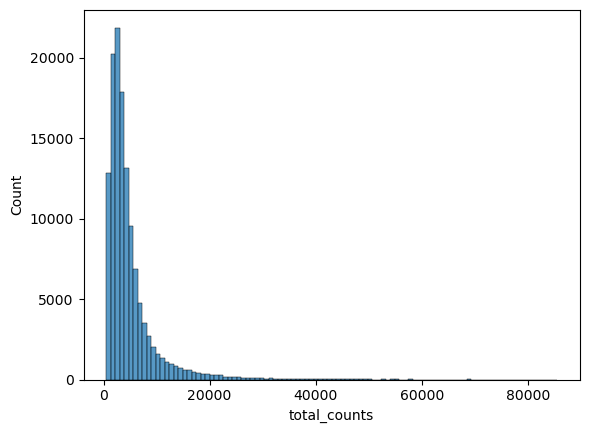

In [37]:
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False)

## Shifted logarithm 

In [38]:
scales_counts = sc.pp.normalize_total(adata, target_sum=None, inplace=False)
# log1p transform
adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

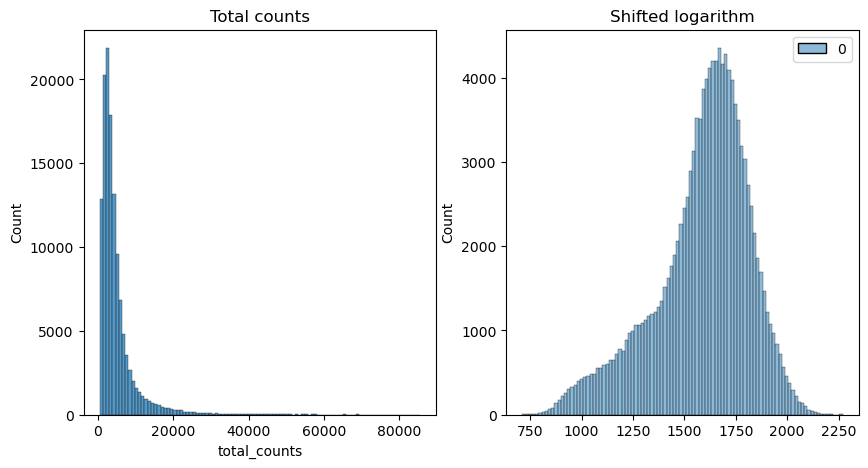

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(adata.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
plt.show()

## Scran's pooling-based size factor estimation method

In [3]:
%load_ext rpy2.ipython

In [41]:
%%R
library(scran)
library(BiocParallel)

In [42]:
# Preliminary clustering for differentiated normalisation
adata_pp = adata.copy()
sc.pp.normalize_total(adata_pp)
sc.pp.log1p(adata_pp)
sc.pp.pca(adata_pp, n_comps=15)
sc.pp.neighbors(adata_pp)
sc.tl.leiden(
    adata_pp, key_added="groups", flavor="igraph", n_iterations=2, directed=False
)

/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [43]:
data_mat = adata_pp.X.T
# convert to CSC if possible. See https://github.com/MarioniLab/scran/issues/70
if issparse(data_mat):
    if data_mat.nnz > 2**31 - 1:
        data_mat = data_mat.tocoo()
    else:
        data_mat = data_mat.tocsc()
    # Convert sparse matrix to dense numpy array
    data_mat = data_mat.toarray()

with localconverter(ro.default_converter + numpy2ri.converter):
    ro.globalenv["data_mat"] = data_mat

with localconverter(ro.default_converter + pandas2ri.converter):
    ro.globalenv["input_groups"] = adata_pp.obs["groups"]

In [44]:
del adata_pp

In [45]:
%%R -o size_factors

size_factors = sizeFactors(
    computeSumFactors(
        SingleCellExperiment(
            list(counts=data_mat)), 
            clusters = input_groups,
            min.mean = 0.1,
            BPPARAM = MulticoreParam()
    )
)

In [46]:
adata.obs["size_factors"] = size_factors
scran = adata.X / adata.obs["size_factors"].values[:, None]
scran_logged = np.log1p(scran)
adata.layers["scran_normalization"] = csr_matrix(scran_logged)

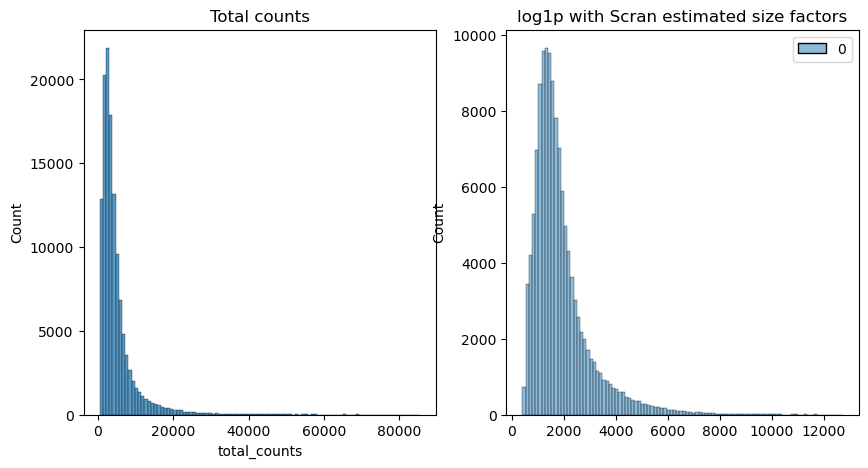

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(
    adata.layers["scran_normalization"].sum(1), bins=100, kde=False, ax=axes[1]
)
axes[1].set_title("log1p with Scran estimated size factors")
plt.show()

## Analytic Pearson residuals

In [48]:
analytic_pearson = sc.experimental.pp.normalize_pearson_residuals(adata, inplace=False)
adata.layers["analytic_pearson_residuals"] = csr_matrix(analytic_pearson["X"])

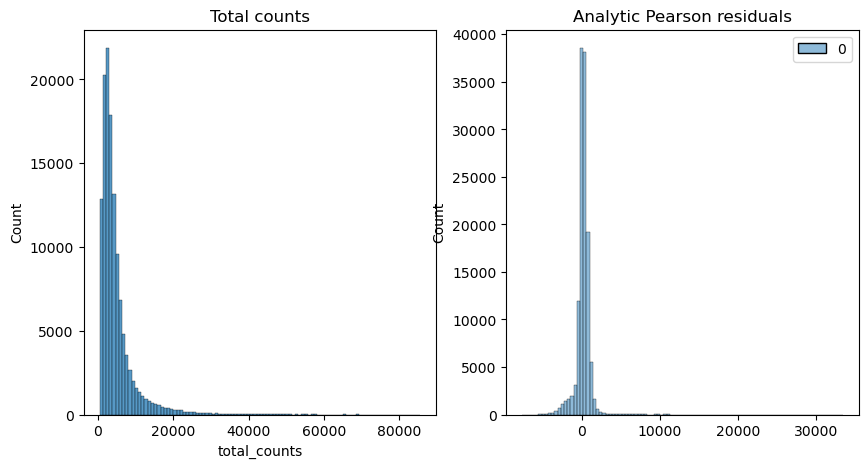

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(
    adata.layers["analytic_pearson_residuals"].sum(1), bins=100, kde=False, ax=axes[1]
)
axes[1].set_title("Analytic Pearson residuals")
plt.show()

In [54]:
adata.var.columns

Index(['gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb',
       'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts',
       'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts',
       'n_cells'],
      dtype='object')

In [ ]:
# not in general, here possible because gene id and important information were not identified as object and therefore not changed
for col in adata.var.columns:
    if adata.var[col].dtype == "object":
        adata.var[col] = adata.var[col].fillna(False).astype(bool)

/tmp/ipykernel_3526314/2912113866.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  adata.var[col] = adata.var[col].fillna(False).astype(bool)
/tmp/ipykernel_3526314/2912113866.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  adata.var[col] = adata.var[col].fillna(False).astype(bool)


In [64]:
adata.write("/projects/circ_iri/work/sc_analysis/normalization/adata_concat_normalized.h5ad")

# Feature selection

In [2]:
adata = sc.read_h5ad("/projects/circ_iri/work/sc_analysis/normalization/adata_concat_normalized.h5ad", chunk_size = 20000)

In [6]:
adata.var

,gene_ids,feature_types,genome,mt,ribo,hb,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells
0610005C13Rik,ENSMUSG00000109644,Gene Expression,GRCm39,False,False,False,217.0,0.016733,0.016594,98.679647,275.0,5.620401,195.0
0610009B22Rik,ENSMUSG00000007777,Gene Expression,GRCm39,False,False,False,978.0,0.068634,0.066381,94.049285,1128.0,7.029088,789.0
0610009E02Rik,ENSMUSG00000086714,Gene Expression,GRCm39,False,False,False,918.0,0.061941,0.060098,94.414360,1018.0,6.926577,825.0
0610009L18Rik,ENSMUSG00000043644,Gene Expression,GRCm39,False,False,False,555.0,0.037724,0.037030,96.623061,620.0,6.431331,468.0
0610010K14Rik,ENSMUSG00000020831,Gene Expression,GRCm39,False,False,False,988.0,0.068208,0.065983,93.988439,1121.0,7.022868,798.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
mt-Nd3,ENSMUSG00000064360,Gene Expression,GRCm39,True,False,False,3600.0,0.261454,0.232265,78.095528,4297.0,8.365905,2956.0
mt-Nd4,ENSMUSG00000064363,Gene Expression,GRCm39,True,False,False,14978.0,3.467113,1.496742,8.865227,56982.0,10.950508,13159.0
mt-Nd4l,ENSMUSG00000065947,Gene Expression,GRCm39,True,False,False,1548.0,0.102890,0.097934,90.581077,1691.0,7.433667,1298.0
mt-Nd5,ENSMUSG00000064367,Gene Expression,GRCm39,True,False,False,8738.0,0.857317,0.619133,46.832978,14090.0,9.553291,7267.0


In [4]:
%%R
library(scry)
library(SingleCellExperiment)

Loading required package: SummarizedExperiment
Loading required package: MatrixGenerics
Loading required package: matrixStats

Attaching package: ‘MatrixGenerics’

The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    rowOrderStats, rowProds, rowQuantiles, rowRanges, ro

In [5]:
X_sparse = adata.X.T.tocoo()

Matrix = rpackages.importr("Matrix")

with localconverter(ro.default_converter + pandas2ri.converter + numpy2ri.converter):
    ro.globalenv["obs"] = adata.obs
    ro.globalenv["var"] = adata.var

i, j = X_sparse.row, X_sparse.col
x = X_sparse.data

ro.globalenv["i"] = ro.IntVector((i + 1).tolist())  # R is 1-indexed
ro.globalenv["j"] = ro.IntVector((j + 1).tolist())
ro.globalenv["x"] = ro.FloatVector(x.tolist())

r("X <- sparseMatrix(i = i, j = j, x = x, dims = c({}, {}))".format(*X_sparse.shape))

In [6]:
%%R
print(dim(X))
print(dim(obs))
print(dim(var))


[1]  20690 127419
[1] 127419     26
[1] 20690    13


In [7]:
%%R
sce <- SingleCellExperiment(
  assays = list(X = X),
  colData = obs,
  rowData = var
)



In [8]:
%%R
sce <- devianceFeatureSelection(sce, assay = "X")

In [9]:
with localconverter(ro.default_converter + pandas2ri.converter + numpy2ri.converter):
    binomial_deviance = ro.r("rowData(sce)$binomial_deviance")

In [10]:
idx = binomial_deviance.argsort()[-4000:]
mask = np.zeros(adata.var_names.shape, dtype=bool)
mask[idx] = True

adata.var["highly_deviant"] = mask
adata.var["binomial_deviance"] = binomial_deviance

In [11]:
sc.pp.highly_variable_genes(adata, layer="scran_normalization")

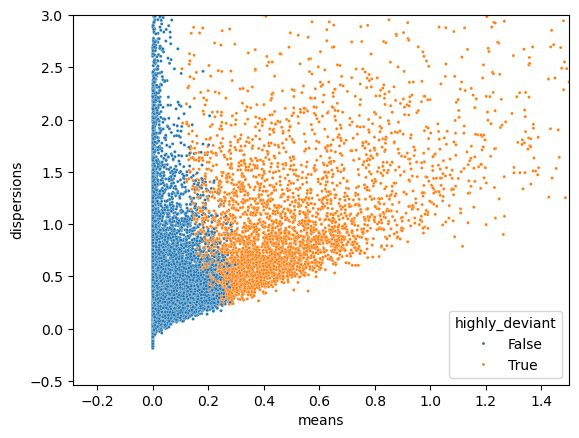

In [12]:
ax = sns.scatterplot(
    data=adata.var, x="means", y="dispersions", hue="highly_deviant", s=5
)
ax.set_xlim(None, 1.5)
ax.set_ylim(None, 3)
plt.show()

In [13]:
adata.var["highly_deviant"].sum()

np.int64(4000)

In [14]:
adata.write("/projects/circ_iri/work/sc_analysis/feature_selection/adata_concat_feature_selection.h5ad")